# Hebrew Vocab Hub — Exploratory Data Analysis

This notebook explores the dataset behind [Hebrew Vocab Hub](https://github.com/gzappaa/hebrew_vocab_hub_API) —
~13,865 Hebrew word forms, 6,069 lemma entries, and 150,806 conjugation cells,
scraped from songs, news, and YouTube comments.

Covers: baseline dataset counts, vocabulary size/structure, part-of-speech
distribution, root productivity, example sentence coverage, and word frequency
distribution (including a Zipf's law check).

Data pulled from a local Postgres instance — see the main repo for schema details.

## Baseline Counts

Row counts across all tables — the anchor numbers for every ratio/percentage
calculated later in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

sns.set_theme(style="whitegrid")

## Vocabulary Size & Structure

Lemma count, distinct Hebrew surface forms, word forms, conjugation cells,
and the share of words with more than one meaning.

In [2]:
tables = ["roots", "lemmas", "words", "word_lemmas", "conj_tables", "conj_cells", "sentences", "word_sources"]
for t in tables:
    count = pd.read_sql(f"SELECT COUNT(*) FROM {t}", engine).iloc[0, 0]
    print(f"{t}: {count}")

roots: 1665
lemmas: 6069
words: 13865
word_lemmas: 18439
conj_tables: 9539
conj_cells: 150806
sentences: 33982
word_sources: 13865


In [3]:
n_lemmas = pd.read_sql("SELECT COUNT(*) FROM lemmas", engine).iloc[0,0]
n_hebrew_forms = pd.read_sql("SELECT COUNT(DISTINCT hebrew) FROM lemmas", engine).iloc[0,0]
n_words = pd.read_sql("SELECT COUNT(*) FROM words", engine).iloc[0,0]
n_cells = pd.read_sql("SELECT COUNT(*) FROM conj_cells", engine).iloc[0,0]


# multiple meanings
df = pd.read_sql("SELECT word_id, lemma_id FROM word_lemmas", engine)
meanings_per_word = df.groupby("word_id")["lemma_id"].nunique()

n_multi = (meanings_per_word > 1).sum()
n_total = pd.read_sql("SELECT COUNT(*) FROM words", engine).iloc[0,0]





avg_conj_per_lemma = pd.read_sql("""
    SELECT AVG(cnt) FROM (
        SELECT ct.lemma_id, COUNT(cc.id) AS cnt
        FROM conj_tables ct
        JOIN conj_cells cc ON cc.table_id = ct.id
        GROUP BY ct.lemma_id
    ) sub
""", engine).iloc[0,0]

print(f"Distinct lemma entries: {n_lemmas}")
print(f"Distinct Hebrew surface forms: {n_hebrew_forms}")
print(f"Total inflected word forms: {n_words}")
print(f"Total conjugation cells: {n_cells}")
print(f"{n_multi} / {n_total} words have multiple meanings ({n_multi/n_total*100:.1f}%)")
print(f"Avg conjugation cells per lemma: {avg_conj_per_lemma:.1f}")

Distinct lemma entries: 6069
Distinct Hebrew surface forms: 5981
Total inflected word forms: 13865
Total conjugation cells: 150806
3471 / 13865 words have multiple meanings (25.0%)
Avg conjugation cells per lemma: 25.7


## Part of Speech Distribution

Distribution of lemmas across grammatical categories (noun, verb, adjective,
etc.). Minor sub-pattern categories (e.g. specific noun/verb patterns) are
grouped under their parent category for readability; categories under 2%
of the total are grouped into "Other."
    

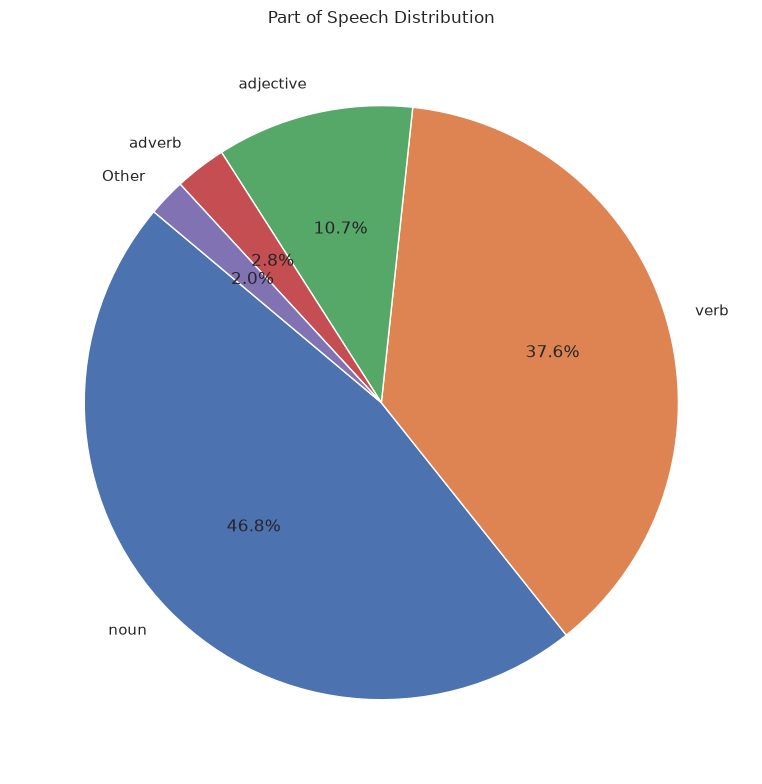

In [4]:
pos_df = pd.read_sql(
    """
    SELECT part_of_speech_plain, COUNT(*) AS n
    FROM lemmas
    WHERE part_of_speech_plain IS NOT NULL
    GROUP BY part_of_speech_plain
    ORDER BY n DESC
""",
    engine,
)

# 1. Standardize text to lowercase to ensure clean matching
pos_df["part_of_speech_plain"] = pos_df["part_of_speech_plain"].str.strip()

# 2. Group categories by checking their starting prefix
for prefix in ["noun", "verb", "adjective", "adverb", "preposition", "pronoun", "cardinal numeral"]:
    mask = pos_df["part_of_speech_plain"].str.startswith(prefix, na=False)
    pos_df.loc[mask, "part_of_speech_plain"] = prefix

# 3. Recalculate sums for the newly combined categories
pos_df = (
    pos_df.groupby("part_of_speech_plain", as_index=False)["n"]
    .sum()
    .sort_values(by="n", ascending=False)
)

pos_df = pos_df[pos_df["part_of_speech_plain"].str.strip() != ""]

# 4. Filter the remaining long tail into 'Other'
total_n = pos_df["n"].sum()
threshold = 0.02 * total_n

major_df = pos_df[pos_df["n"] >= threshold].copy()
minor_df = pos_df[pos_df["n"] < threshold]

if not minor_df.empty:
    other_row = pd.DataFrame(
        [{"part_of_speech_plain": "Other", "n": minor_df["n"].sum()}]
    )
    plot_df = pd.concat([major_df, other_row], ignore_index=True)
else:
    plot_df = major_df

# 5. Plot the final cleaned distribution
plt.figure(figsize=(8, 8))
plt.pie(
    plot_df["n"],
    labels=plot_df["part_of_speech_plain"],
    autopct="%1.1f%%",
    startangle=140,
)
plt.title("Part of Speech Distribution")
plt.tight_layout()
plt.show()

## Root Productivity

Hebrew builds vocabulary through a root-and-pattern system — this section
shows which 3-letter roots generate the largest families of derived words
in the dataset.

Unique roots: 1665


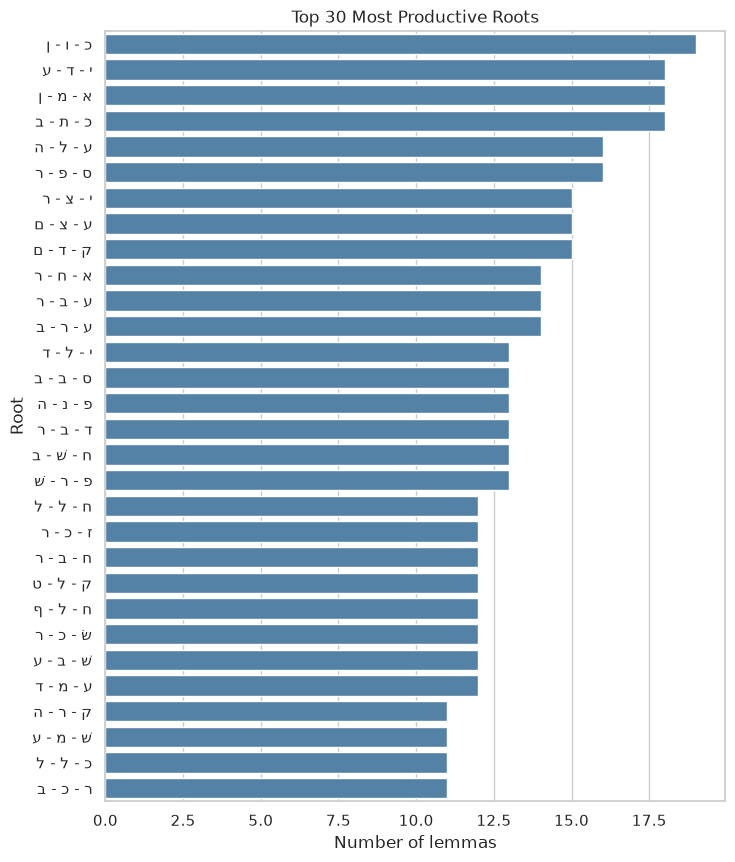

In [5]:
roots_df = pd.read_sql("""
    SELECT r.display AS root, COUNT(l.id) AS n_lemmas
    FROM roots r
    JOIN lemmas l ON l.root_id = r.id
    GROUP BY r.display
    ORDER BY n_lemmas DESC
    LIMIT 30
""", engine)

n_unique_roots = pd.read_sql("SELECT COUNT(*) FROM roots", engine).iloc[0,0]
print(f"Unique roots: {n_unique_roots}")

plt.figure(figsize=(8,10))
sns.barplot(data=roots_df, y="root", x="n_lemmas", color="steelblue")
plt.title("Top 30 Most Productive Roots")
plt.xlabel("Number of lemmas")
plt.ylabel("Root")
plt.show()

## Example Sentence Coverage

What share of words have at least one bilingual example sentence, and how
many sentences per word on average where present.

In [6]:
coverage = pd.read_sql("""
    SELECT
        COUNT(DISTINCT w.id) AS total_words,
        COUNT(DISTINCT s.word_id) AS words_with_sentences
    FROM words w
    LEFT JOIN sentences s ON s.word_id = w.id
""", engine)

pct = coverage["words_with_sentences"][0] / coverage["total_words"][0] * 100
print(f"Words with at least one example sentence: {pct:.1f}%")

avg_sentences = pd.read_sql("""
    SELECT AVG(cnt) FROM (
        SELECT word_id, COUNT(*) AS cnt FROM sentences GROUP BY word_id
    ) sub
""", engine).iloc[0,0]
print(f"Avg example sentences per word (where present): {avg_sentences:.2f}")

Words with at least one example sentence: 99.3%
Avg example sentences per word (where present): 2.47


## Frequency Distribution & Zipf's Law

Word frequency here is the sum of appearances across songs, news, and
YouTube comments. This section checks whether the distribution follows
the classic Zipfian pattern seen in natural language.

This dataset's frequency values are cross-source aggregates (songs + news + YouTube), not a controlled linguistic corpus — so this should be read as "how often a word appeared across our specific scraped sources," not as a general claim about Hebrew word frequency in the wild.

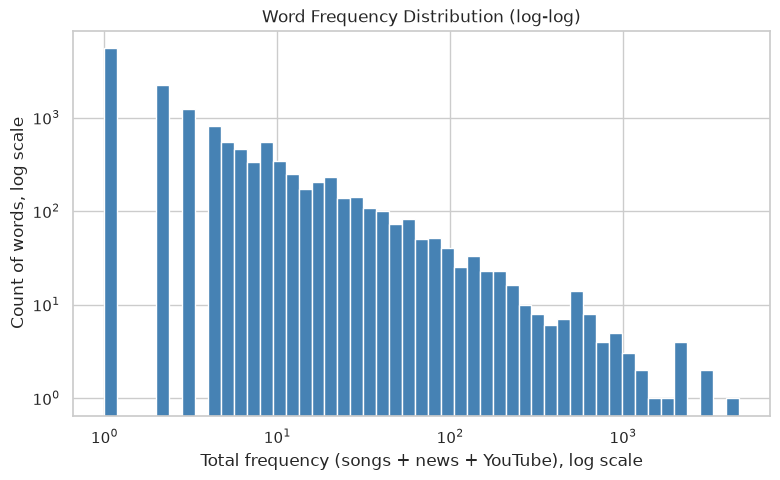

In [7]:
import numpy as np

freq_df = pd.read_sql("SELECT total FROM word_sources WHERE total > 0", engine)

data = freq_df["total"].values
bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)

plt.figure(figsize=(9,5))
plt.hist(data, bins=bins, color="steelblue", edgecolor="white")
plt.xscale("log")
plt.yscale("log")
plt.title("Word Frequency Distribution (log-log)")
plt.xlabel("Total frequency (songs + news + YouTube), log scale")
plt.ylabel("Count of words, log scale")
plt.show()

In [8]:
from scipy import stats

log_data = np.log10(data)
counts, bin_edges = np.histogram(data, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# only fit where counts > 0 (log of 0 is undefined)
mask = counts > 0
slope, intercept, r_value, p_value, std_err = stats.linregress(
    np.log10(bin_centers[mask]), np.log10(counts[mask])
)

print(f"Power-law exponent (slope): {slope:.2f}")
print(f"R-squared: {r_value**2:.3f}")

Power-law exponent (slope): -1.00
R-squared: 0.977


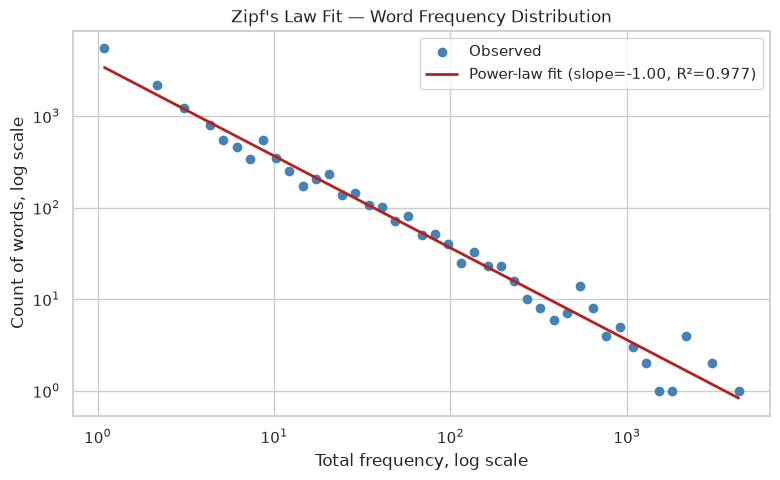

In [9]:
plt.figure(figsize=(9,5))

# actual data points (bin centers vs counts, both log scale)
plt.scatter(bin_centers[mask], counts[mask], color="steelblue", label="Observed")

# fitted power-law line
fit_x = bin_centers[mask]
fit_y = 10**(intercept + slope * np.log10(fit_x))
plt.plot(fit_x, fit_y, color="firebrick", linewidth=2,
          label=f"Power-law fit (slope={slope:.2f}, R²={r_value**2:.3f})")

plt.xscale("log")
plt.yscale("log")
plt.title("Zipf's Law Fit — Word Frequency Distribution")
plt.xlabel("Total frequency, log scale")
plt.ylabel("Count of words, log scale")
plt.legend()
plt.show()

## Zipf's Law Check

Fitting a power law to the log-log word frequency distribution yields:

- **Exponent (slope): -1.00**
- **R² : 0.977**

This is a close match to the canonical Zipf's law exponent of -1, indicating
strong Zipfian behavior — a small number of words account for a disproportionate
share of total occurrences, while the vast majority of words appear only once
or twice across the combined songs/news/YouTube corpus.

**Caveat:** these frequencies reflect the specific sources scraped for this
project (songs, news, YouTube comments), not general spoken/written Hebrew —
so this confirms the *shape* of the distribution follows natural language
patterns, without claiming the exact word rankings represent broader usage.

In [10]:
# Top 20 words by total frequency
ranked_words = pd.read_sql("""
    SELECT w.word, ws.total
    FROM words w
    JOIN word_sources ws ON ws.word_id = w.id
    WHERE ws.total > 0
    ORDER BY ws.total DESC
""", engine)

ranked_words["rank"] = ranked_words.index + 1
ranked_words[["rank", "word", "total"]].head(20)

,rank,word,total
0,1,את,4665
1,2,לא,3299
2,3,של,2996
3,4,על,2321
4,5,אני,2295
5,6,זה,2046
6,7,לי,1973
7,8,ב,1709
8,9,שיר,1516
9,10,עם,1335
